#Sentiment Analysis Data Thesis (Ana Encinas)

##Instalations

In [1]:
# Installing transformers, datasets and python packages in the environment
!pip install datasets
!pip install torch -U
!pip install accelerate -U
!pip install optuna
!pip install --upgrade transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system =

In [2]:
from datasets import load_dataset, Dataset, DatasetDict
#from transformers import BertTokenizer
import pandas as pd

##Loading the dataset

In [3]:
from datasets import load_dataset, Dataset, DatasetDict
import pandas as pd
# Step 1: Load full dataset
dataset_raw = load_dataset('tweet_eval', 'sentiment')
df_full = dataset_raw['train'].to_pandas()

# Step 2: Balance classes (limit to 3333 per class)
class_counts = df_full['label'].value_counts()
samples_per_class = min(3333, class_counts.min())

balanced_df = pd.concat([
    df_full[df_full['label'] == label].sample(n=samples_per_class, random_state=42)
    for label in class_counts.index
]).sample(frac=1, random_state=42).reset_index(drop=True)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

EDA
Baseline: como de bueno es frente a un modelo basico;

###Create Balanced Dataset

In [4]:
# Step 3: Convert back to Hugging Face Dataset and split
balanced_dataset = Dataset.from_pandas(balanced_df)
shuffled = balanced_dataset.shuffle(seed=42)
train_size = int(0.8 * len(shuffled))

train_dataset = shuffled.select(range(train_size))
test_dataset = shuffled.select(range(train_size, len(shuffled)))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})


### EDA

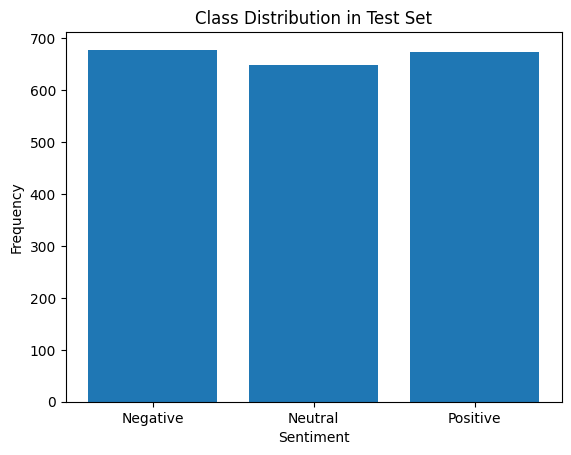

Test Set Class Counts:
Negative: 678
Neutral: 648
Positive: 674


In [5]:
import matplotlib.pyplot as plt

# Check label distribution in test set
label_counts = dataset_dict['test'].to_pandas()['label'].value_counts().sort_index()
label_names = ['Negative', 'Neutral', 'Positive']

plt.bar(label_names, label_counts)
plt.title("Class Distribution in Test Set")
plt.xlabel("Sentiment")
plt.ylabel("Frequency")
plt.show()

print("Test Set Class Counts:")
for i, name in enumerate(label_names):
    print(f"{name}: {label_counts[i]}")

##Logistic Regression

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from datasets import DatasetDict
import pandas as pd

# Step 1: Convert dataset to pandas
train_df = dataset_dict["train"].to_pandas()
test_df = dataset_dict["test"].to_pandas()

# Step 2: Vectorize text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

# Step 3: Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_df["label"])

# Step 4: Evaluate
y_pred = clf.predict(X_test)
print("📉 Logistic Regression (TF-IDF) Baseline:")
print(classification_report(test_df["label"], y_pred, target_names=["Negative", "Neutral", "Positive"]))


📉 Logistic Regression (TF-IDF) Baseline:
              precision    recall  f1-score   support

    Negative       0.65      0.63      0.64       678
     Neutral       0.51      0.54      0.52       648
    Positive       0.64      0.62      0.63       674

    accuracy                           0.60      2000
   macro avg       0.60      0.60      0.60      2000
weighted avg       0.60      0.60      0.60      2000



#Model 1- BERT

###Load the model

In [7]:
from transformers import BertTokenizer, BertForSequenceClassification

# Load tokenizer and model consistently
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
# Step 4: Tokenization - already done above

def tokenize(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

dataset_dict1 = dataset_dict.map(tokenize, batched=True)
dataset_dict1.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Sanity check
print(dataset_dict1)
print(dataset_dict1["train"][0])


Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7999
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})
{'label': tensor(0), 'input_ids': tensor([ 101, 1000, 4840, 2125, 1037, 3951, 5981, 4600, 4208, 2006, 2120, 3036,
        5936, 1010, 6221, 8398, 2006, 9317, 7549, 1996, 4238, 4517, 3066, 2008,
        1000,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0

###Define Metrics

In [9]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

###Set Up TrainingArguments and Trainer

In [10]:
print(dataset_dict1["train"][0])

{'label': tensor(0), 'input_ids': tensor([ 101, 1000, 4840, 2125, 1037, 3951, 5981, 4600, 4208, 2006, 2120, 3036,
        5936, 1010, 6221, 8398, 2006, 9317, 7549, 1996, 4238, 4517, 3066, 2008,
        1000,  102,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1,

In [11]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # Change this line
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_dict1["train"],
    eval_dataset=dataset_dict1["test"],
    compute_metrics=compute_metrics,
)


###Train the model

In [12]:
trainer.train()
#ec5ac6d40d911775068afac0cc3bce109b5411ab

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aencinas-ieu2020 (aencinas-ieu2020-ie-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.754500,0.684459,0.708500,0.703594
2,0.431200,0.715740,0.717000,0.717013


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.754500,0.684459,0.708500,0.703594
2,0.431200,0.715740,0.717000,0.717013
3,0.192200,1.118203,0.704000,0.704257


TrainOutput(global_step=1500, training_loss=0.45929964192708334, metrics={'train_runtime': 600.4317, 'train_samples_per_second': 39.966, 'train_steps_per_second': 2.498, 'total_flos': 1578483171304704.0, 'train_loss': 0.45929964192708334, 'epoch': 3.0})

###Evaluate Model

In [13]:
trainer.evaluate()

{'eval_loss': 0.68445885181427,
 'eval_accuracy': 0.7085,
 'eval_f1': 0.7035935232625401,
 'eval_runtime': 14.1645,
 'eval_samples_per_second': 141.198,
 'eval_steps_per_second': 8.825,
 'epoch': 3.0}

##Manual Sentiment Prediction

In [ ]:
import torch
from transformers import pipeline

# Load the fine-tuned model from the Trainer
sentiment_classifier = pipeline(
    "text-classification",
    model=trainer.model,
    tokenizer=tokenizer,
    return_all_scores=True,
    device=0 if torch.cuda.is_available() else -1
)

In [15]:
#The following posts were intentionally selected for being emotionally ambiguous or deceptive using tools.
#Many of the massages use tools such as sarcasm, irony, mixed emotions as well as misleading positivity and negativity.
#Thus, making it harder for the model to detect the emotionality

posts = [
  "I'm so glad I stayed up all night just to be ignored in the morning.",
  "Love it when my plans fall apart at the last minute. Classic me!",
  "Just got the job I’ve been dreaming of — feeling unstoppable!",
  "I’m fine. Just tired, as usual.",
  "I don’t think I can take much more of this stress.",
  "Nothing makes me feel more alive than pretending everything's okay.",
  "Great. Another ‘we need to talk’ message. Can’t wait",
  "I smiled through the whole thing, but inside I felt like crumbling.",
  "At least I’m used to disappointment by now.",
  "Today was productive and peaceful. Grateful for the small wins.",
  "Promotion went to someone else. They really deserved it.",
  "I guess pretending to be happy counts as being happy, right?",
  "Wow, someone actually texted me first… wonder what they want.",
  "Had a ‘wonderful’ meeting that totally wasn’t a waste of time.",
  "Got out of bed today. That’s enough for now.",
  "Heading to the gym after work. Hope it’s not too crowded.",
  "Everything hurts, but I’m still posting selfies so it’s fine.",
  "People say I seem so positive — maybe that’s the problem.",
  "I just want to stay in bed and disappear for a while.",
  "I laughed at the joke. Didn’t mention it was about me.",
  "I'm curios... was the goal to put on weight? No hate just an honest question..."
]

label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}



In [24]:
posts = [
  "I'm so glad I stayed up all night just to be ignored in the morning.",
  "Love it when my plans fall apart at the last minute. Classic me!",
  "Just got the job I’ve been dreaming of — feeling unstoppable!",
  "I’m fine. Just tired, as usual.",
  "I don’t think I can take much more of this stress.",
  "Nothing makes me feel more alive than pretending everything's okay.",
  "Great. Another ‘we need to talk’ message. Can’t wait",
  "I smiled through the whole thing, but inside I felt like crumbling.",
  "At least I’m used to disappointment by now.",
  "Today was productive and peaceful. Grateful for the small wins.",
  "Promotion went to someone else. Guess they really deserved it.",
  "I guess pretending to be happy counts as being happy, right?",
  "Wow, someone actually texted me first… wonder what they want.",
  "Had a ‘wonderful’ meeting that totally wasn’t a waste of time.",
  "Got out of bed today. That’s enough for now.",
  "Heading to the gym after work. Hope it’s not too crowded.",
  "Everything hurts, but I’m still posting selfies so it’s fine.",
  "People say I seem so positive — maybe that’s the problem.",
  "I just want to stay in bed and disappear for a while.",
  "I laughed at the joke. Didn’t mention it was about me.",
  "Proof bullying is good.",
  "I don't know what your problem is, but I bet it's hard to pronounce.",
  "I hope your day is as pleasant as you are!",
  "I'm curious... was the goal to put on weight? No hate just an honest question...",
  "I don't have the time or the crayons to explain it to you.",
  "Wah, stop crying and get a job.",
  "Who records themselves crying 😂 cool.",
  "Made me tear up :( I doubt anyone in my life will notice my absence either.",
  "I feel like I haven't smiled in a year and a half that was wonderful."
]

label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive"
}

In [25]:
#Get the results:
results = sentiment_classifier(posts)

for text, res in zip(posts, results):
    top_label = max(res, key=lambda x: x["score"])
    print(f"\n Post: {text}")
    print(f" Predicted Sentiment: {label_map[top_label['label']]} ({top_label['score']:.2f})")


 Post: I'm so glad I stayed up all night just to be ignored in the morning.
 Predicted Sentiment: Negative (0.73)

 Post: Love it when my plans fall apart at the last minute. Classic me!
 Predicted Sentiment: Positive (0.64)

 Post: Just got the job I’ve been dreaming of — feeling unstoppable!
 Predicted Sentiment: Positive (0.79)

 Post: I’m fine. Just tired, as usual.
 Predicted Sentiment: Negative (0.76)

 Post: I don’t think I can take much more of this stress.
 Predicted Sentiment: Negative (0.90)

 Post: Nothing makes me feel more alive than pretending everything's okay.
 Predicted Sentiment: Positive (0.68)

 Post: Great. Another ‘we need to talk’ message. Can’t wait
 Predicted Sentiment: Positive (0.94)

 Post: I smiled through the whole thing, but inside I felt like crumbling.
 Predicted Sentiment: Negative (0.78)

 Post: At least I’m used to disappointment by now.
 Predicted Sentiment: Negative (0.86)

 Post: Today was productive and peaceful. Grateful for the small wins.
 P

#Model 2- Roberta

In [18]:
from transformers import RobertaTokenizer, RobertaForSequenceClassification

# Load tokenizer and model
roberta_tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=3)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
# Tokenization function for Roberta
def roberta_tokenize(batch):
    return roberta_tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

# Apply tokenization
roberta_dataset = dataset_dict.map(roberta_tokenize, batched=True)
roberta_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

###Define Metrics

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}


###Set Up TrainingArguments and Trainer

In [ ]:
from transformers import TrainingArguments, Trainer

roberta_args = TrainingArguments(
    output_dir="./roberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./roberta_logs",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_args,
    train_dataset=roberta_dataset["train"],
    eval_dataset=roberta_dataset["test"],
    compute_metrics=compute_metrics
)


In [22]:
roberta_trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.777300,0.695199,0.710500,0.706091
2,0.538800,0.672552,0.719500,0.720379
3,0.330000,0.822510,0.721000,0.718671


TrainOutput(global_step=1500, training_loss=0.5487006937662761, metrics={'train_runtime': 600.9747, 'train_samples_per_second': 39.93, 'train_steps_per_second': 2.496, 'total_flos': 1578483171304704.0, 'train_loss': 0.5487006937662761, 'epoch': 3.0})

In [23]:
roberta_trainer.evaluate()


{'eval_loss': 0.6725521087646484,
 'eval_accuracy': 0.7195,
 'eval_f1': 0.7203791619313542,
 'eval_runtime': 12.8881,
 'eval_samples_per_second': 155.182,
 'eval_steps_per_second': 9.699,
 'epoch': 3.0}